# Data collection to learn detuning dynamics of a radio frequency cavity

In [1]:
import os
import sys

cur_dir = os.getcwd()
root_dir = os.path.abspath(os.path.join(cur_dir, '..', '..'))
sys.path.append(root_dir)

import numpy as np
import matplotlib.pyplot as plt

import care

In [2]:
# --! specify cavity parameters --!

parser = care.create_args_parser()

args = parser.parse_args(
    args=[
        '-fg', '1.3e9',
        '-ig', '0.016',
        '-og', '-460.0',

        '-rc', '1036',
        '-qc', '3e6',

        '-ga', '12e6',

        '-fm', '280, 341, 460, 487, 618',
        '-qm', '40, 20, 50, 80, 100',
        '-km', '2, 0.8, 2, 0.6, 0.2',

        '-ib', '0.008',
        '-nb', '15000',

        '-nf', '5000',

        '-ts', '1e-6',
        '-ns', '35000',
    ]
)


In [3]:
# --! create cavity simulator --!

sim = care.simulator(args)

In [4]:
# --! simulate --!

sim_nsample = 2048 * 16

vc  = np.zeros(sim_nsample, dtype=complex)
dc  = np.zeros(sim_nsample)

sim.reset()

for i in range(sim_nsample):
    vc[i], dc[i] = sim.step(0.0)

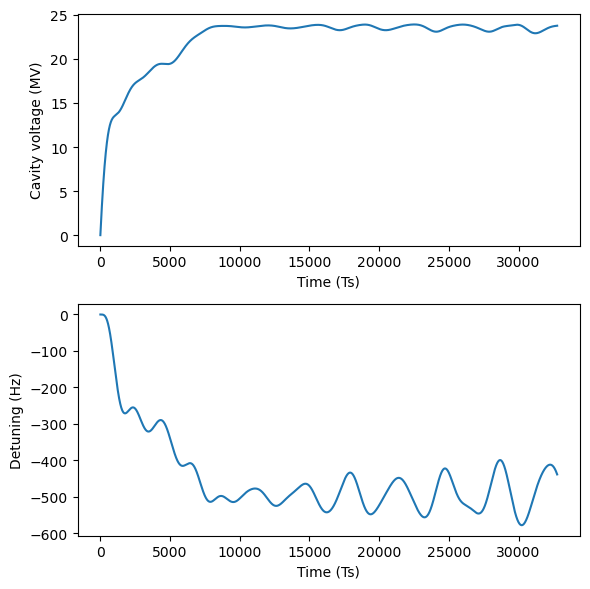

In [5]:
# --! plot simulation results --!

plt.figure(figsize=(6, 6))

plt.subplot(2,1,1)
plt.plot(abs(vc) * 1e-6)
plt.xlabel('Time (Ts)')
plt.ylabel('Cavity voltage (MV)')

plt.subplot(2,1,2)
plt.plot(dc / 2 / np.pi)
plt.xlabel('Time (Ts)')
plt.ylabel('Detuning (Hz)')

plt.tight_layout()
plt.show()